In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
# ÉTAPE 1 : CHARGER LE DATASET
df=pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [3]:
df.head()
df.shape

(1460, 81)

In [4]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df['SalePrice'].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

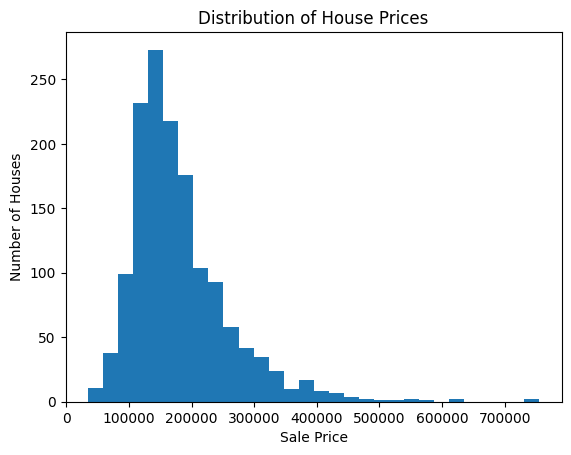

In [9]:
import matplotlib.pyplot as plt
plt.hist(df['SalePrice'],bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

Text(0.5, 1.0, 'Overall Quality vs Sale Price')

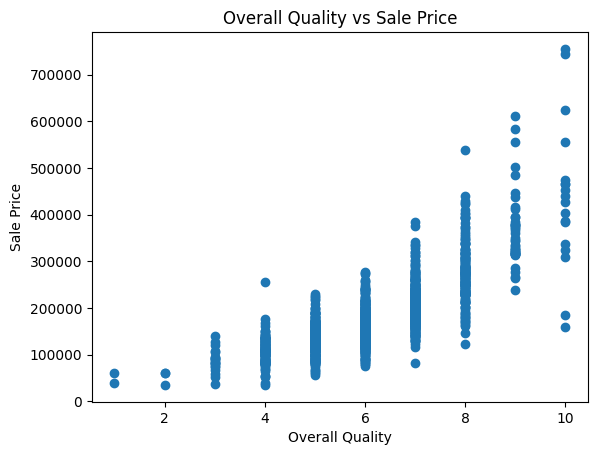

In [10]:
plt.scatter(df["OverallQual"],df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")

Text(0.5, 1.0, 'Living Area vs Sale Price')

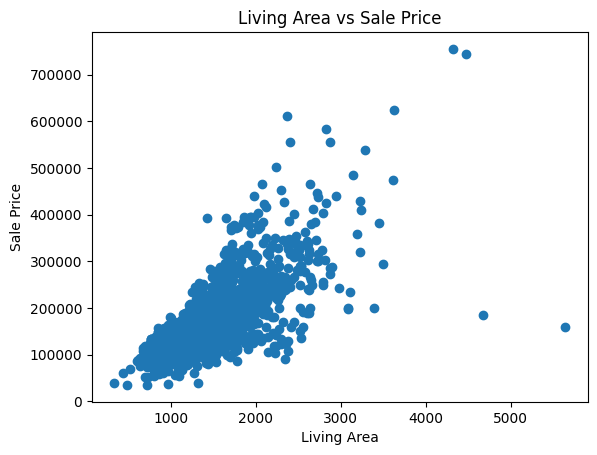

In [11]:
plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")

In [12]:
numeric_df = df.select_dtypes(include=["number"])
correlations=numeric_df.corr()["SalePrice"]
correlations.sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [13]:

top_correlations = correlations.sort_values(
    ascending=False
).head(10)

top_correlations

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [14]:
y = df["SalePrice"]
X=df.drop(columns=["SalePrice"])
print("Taille de X :", X.shape)
print("Taille de y :", y.shape)
X = X.drop(columns=["Id"])

Taille de X : (1460, 80)
Taille de y : (1460,)


In [15]:
numeric_columns =X.select_dtypes(include=["number"]).columns
numeric_columns 

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [16]:
len(numeric_columns)

36

In [17]:
categorical_columns =X.select_dtypes(include=["object"]).columns
categorical_columns 

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [18]:
print("Numériques :", len(numeric_columns))
print("Catégorielles :", len(categorical_columns))
print("Total :", len(numeric_columns) + len(categorical_columns))

Numériques : 36
Catégorielles : 43
Total : 79


In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [20]:
numeric_columns=X_train.select_dtypes(include=["number"]).columns
numeric_missing=X_train[numeric_columns].isnull().sum()
numeric_missing[numeric_missing > 0].sort_values(ascending=False)

LotFrontage    217
GarageYrBlt     64
MasVnrArea       6
dtype: int64

In [21]:
from sklearn.impute import SimpleImputer
numeric_imputer=SimpleImputer(strategy="median")
numeric_imputer.fit(X_train[numeric_columns])

SimpleImputer(strategy='median')

In [22]:
X_train_numeric_imputed=numeric_imputer.transform(X_train[numeric_columns])
X_test_numeric_imputed = numeric_imputer.transform(
    X_test[numeric_columns]
)
np.isnan(X_train_numeric_imputed).sum()

np.int64(0)

In [23]:
categorical_columns=X_train.select_dtypes(include=["object"]).columns
categorical_missing=X_train[categorical_columns].isnull().sum()
categorical_missing[categorical_missing > 0].sort_values(ascending=False)

PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
GarageFinish      64
GarageQual        64
GarageType        64
GarageCond        64
BsmtCond          28
BsmtFinType2      28
BsmtFinType1      28
BsmtQual          28
BsmtExposure      28
Electrical         1
dtype: int64

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline(
    steps=[
        # Étape 1 :
        # remplir les valeurs manquantes.
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # Étape 2 :
        # transformer les catégories en colonnes 0 / 1.
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)
numeric_pipeline = Pipeline(
    steps=[
        # Remplacer les valeurs numériques manquantes
        # par la médiane de chaque colonne.
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [25]:
from sklearn.compose import ColumnTransformer
# Création du preprocessing complet.
#
# On dit à Python :
# - applique numeric_pipeline aux colonnes numériques
# - applique categorical_pipeline aux colonnes catégorielles

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",                 # Nom qu'on donne à cette partie
            numeric_pipeline,      # Pipeline à appliquer
            numeric_columns        # Colonnes concernées
        ),
        (
            "cat",                 # Nom de la partie catégorielle
            categorical_pipeline,  # Pipeline catégorielle
            categorical_columns    # Colonnes concernées
        )
    ]
)

In [26]:
from sklearn.linear_model import LinearRegression


In [27]:
linear_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)


In [28]:
linear_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [29]:
y_pred_linear=linear_model.predict(X_test)

In [30]:
# Afficher les 10 premiers prix prédits.

y_pred_linear[:10]

array([151971.20051183, 356441.14089892,  95590.88330007, 177919.63763369,
       342171.21147719,  59615.31585659, 253448.9505881 , 153388.03759418,
        53796.95852136, 149553.68215884])

In [31]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_linear
})

comparison.head(10)

,Actual Price,Predicted Price
0,154500,151971.200512
1,325000,356441.140899
2,115000,95590.883300
3,159000,177919.637634
4,315500,342171.211477
5,75500,59615.315857
6,311500,253448.950588
7,146000,153388.037594
8,84500,53796.958521
9,135500,149553.682159


In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [33]:
mae_linear=mean_absolute_error(
    y_test,y_pred_linear
)
mae_linear

20466.133695662054

In [34]:
mse_linear=mean_squared_error(
    y_test,
    y_pred_linear
)
rmse_linear=np.sqrt(mse_linear)
rmse_linear

np.float64(31294.99097443936)

In [35]:
r2_linear=r2_score(
    y_test,
    y_pred_linear
)
r2_linear

0.8723161918234245

In [36]:
from sklearn.tree import DecisionTreeRegressor

In [37]:
tree_model=Pipeline(
    steps=[
    ("preprocessor",preprocessor),
    ("model",DecisionTreeRegressor(random_state=42))
]
)

In [38]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [39]:
y_pred_tree=tree_model.predict(X_test)

In [40]:

mae_tree = mean_absolute_error(
    y_test,
    y_pred_tree
)

mse_tree = mean_squared_error(
    y_test,
    y_pred_tree
)

rmse_tree = np.sqrt(mse_tree)

r2_tree = r2_score(
    y_test,
    y_pred_tree
)

In [41]:

print(f"MAE  : ${mae_tree:,.2f}")
print(f"RMSE : ${rmse_tree:,.2f}")
print(f"R²   : {r2_tree:.4f}")

MAE  : $26,452.03
RMSE : $41,191.30
R²   : 0.7788


In [42]:
# Comparer les deux premiers modèles.

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],

    "MAE": [
        mae_linear,
        mae_tree
    ],

    "RMSE": [
        rmse_linear,
        rmse_tree
    ],

    "R²": [
        r2_linear,
        r2_tree
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,20466.133696,31294.990974,0.872316
1,Decision Tree,26452.030822,41191.304665,0.778794


In [43]:
from sklearn.ensemble import RandomForestRegressor

In [44]:
random_forest_model=Pipeline(
    steps=[
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [45]:
random_forest_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [46]:
y_pred_rf=random_forest_model.predict(X_test)

In [47]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

In [48]:
print(f"MAE  : ${mae_rf:,.2f}")
print(f"RMSE : ${rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

MAE  : $17,386.11
RMSE : $28,495.23
R²   : 0.8941


In [49]:

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],

    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],

    "R²": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,20466.133696,31294.990974,0.872316
1,Decision Tree,26452.030822,41191.304665,0.778794
2,Random Forest,17386.105702,28495.231222,0.894140


In [50]:
from xgboost import XGBRegressor

In [51]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [52]:
xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [53]:
y_pred_xgb = xgb_model.predict(X_test)

In [54]:
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

mse_xgb = mean_squared_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(mse_xgb)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

In [55]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf,
        rmse_xgb
    ],

    "R²": [
        r2_linear,
        r2_tree,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,20466.133696,31294.990974,0.872316
1,Decision Tree,26452.030822,41191.304665,0.778794
2,Random Forest,17386.105702,28495.231222,0.894140
3,XGBoost,16061.664062,25061.562601,0.918115


In [56]:
results_sorted=results.sort_values(
    by="RMSE",
    ascending=True
)
results_sorted


,Model,MAE,RMSE,R²
3,XGBoost,16061.664062,25061.562601,0.918115
2,Random Forest,17386.105702,28495.231222,0.894140
0,Linear Regression,20466.133696,31294.990974,0.872316
1,Decision Tree,26452.030822,41191.304665,0.778794


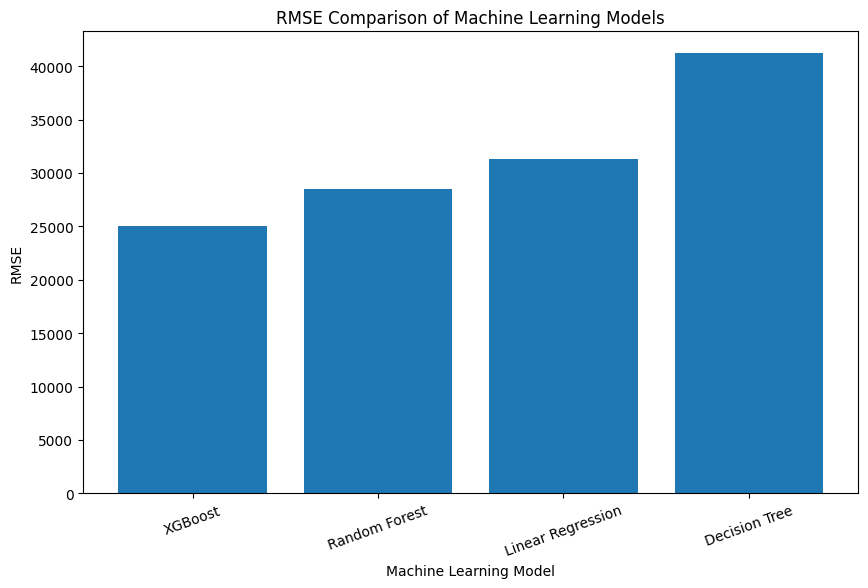

In [57]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_sorted["Model"],
    results_sorted["RMSE"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Machine Learning Models")

# Incliner légèrement les noms pour qu'ils soient lisibles.
plt.xticks(rotation=20)

plt.show()

In [58]:
# Trouver la ligne ayant le RMSE le plus faible.
best_model_row=results.loc[
results["RMSE"].idxmin()
]
best_model_row

Model         XGBoost
MAE      16061.664062
RMSE     25061.562601
R²           0.918115
Name: 3, dtype: object

In [59]:
best_model_name = best_model_row["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [60]:
predictions={
    "Linear Regression": y_pred_linear,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}
best_predictions=predictions[best_model_name]

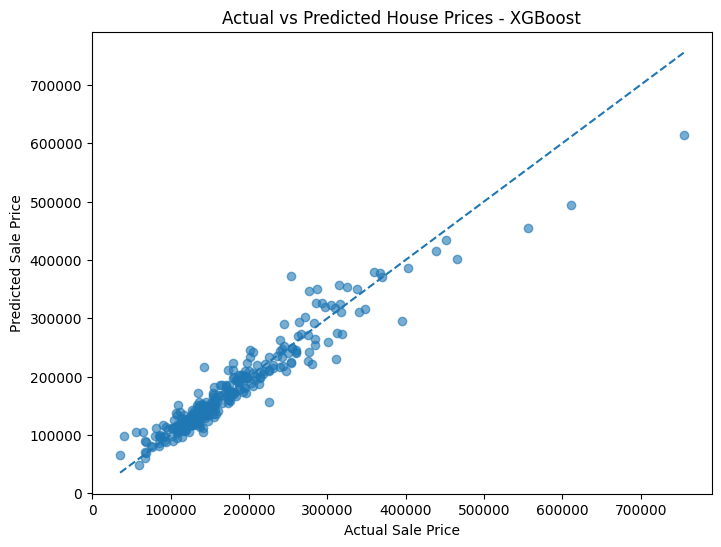

In [61]:

# ACTUAL VS PREDICTED AVEC LIGNE IDÉALE

plt.figure(figsize=(8, 6))

# Afficher les maisons.
plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

# Trouver le prix minimum et maximum
# pour construire la ligne de prédiction parfaite.
min_price = min(
    y_test.min(),
    best_predictions.min()
)

max_price = max(
    y_test.max(),
    best_predictions.max()
)

# Ligne parfaite :
#
# vrai prix = prix prédit
plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title(
    f"Actual vs Predicted House Prices - {best_model_name}"
)

plt.show()

In [62]:
kaggle_test = pd.read_csv(
    "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

# Afficher les 5 premières lignes.
kaggle_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [63]:
kaggle_test_ids = kaggle_test["Id"]
X_kaggle_test = kaggle_test.drop(columns=["Id"])

In [64]:
X_kaggle_test.shape

(1459, 79)

In [65]:
models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

In [66]:
best_model = models[best_model_name]

print("Final model:", best_model_name)

Final model: XGBoost


In [67]:
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [68]:

kaggle_predictions = best_model.predict(
    X_kaggle_test
)

In [69]:
submission = pd.DataFrame({
    "Id": kaggle_test_ids,
    "SalePrice": kaggle_predictions
})

submission.head(10)

,Id,SalePrice
0,1461,123095.015625
1,1462,165554.578125
2,1463,176790.625000
3,1464,186992.187500
4,1465,189845.734375
5,1466,176609.859375
6,1467,165414.812500
7,1468,163327.265625
8,1469,190306.906250
9,1470,127008.335938


In [70]:
submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("submission.csv created successfully!")


submission.csv created successfully!


In [71]:

check_submission = pd.read_csv(
    "/kaggle/working/submission.csv"
)

check_submission.head()

,Id,SalePrice
0,1461,123095.016
1,1462,165554.580
2,1463,176790.620
3,1464,186992.190
4,1465,189845.730


## Conclusion

In this project, several machine learning regression models were developed to predict house sale prices.

The dataset was first explored and preprocessed by handling missing values and encoding categorical variables. The data was then divided into training and testing sets.

Four regression models were evaluated:

- Linear Regression
- Decision Tree
- Random Forest
- XGBoost

The models were compared using **MAE, RMSE, and $R^2$**.

The best-performing model was selected mainly based on the **lowest RMSE**, and its predictions were compared with the actual house prices.

This project demonstrates how machine learning can be used to estimate house prices based on multiple characteristics such as overall quality, living area, year of construction, garage capacity, and other property features.